In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional, Set, Dict
from collections import defaultdict

RANDOM_SEED = 41
np.random.seed(RANDOM_SEED)

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import DataStructs
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

2.1863357142857143
1.2028604901336188
4.5
-1.5


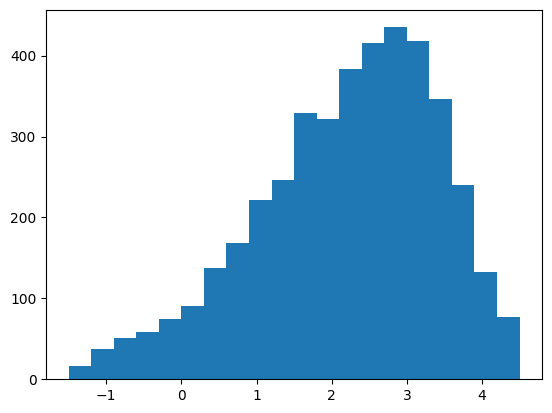

In [33]:
df = pd.read_csv("Lipophilicity.csv")

lipohilicity = df["exp"].to_numpy()

print(lipohilicity.mean())
print(lipohilicity.std())
print(lipohilicity.max())
print(lipohilicity.min())

plt.hist(lipohilicity, bins=20)
plt.show()

In [ ]:
cleaned_smiles = []
cleaned_exp = []
instances = []

for i, row in df.iterrows():
    mol = Chem.MolFromSmiles(df["smiles"][i])

    lfg = rdMolStandardize.LargestFragmentChooser()
    mol = lfg.choose(mol)

    uncharger = rdMolStandardize.Uncharger()
    mol = uncharger.uncharge(mol)

    smiles = Chem.MolToSmiles(mol)

    if not smiles in cleaned_smiles:
        cleaned_smiles.append(smiles)
        cleaned_exp.append(df["exp"][i])
        instances.append(1)
    else:
        duplicate_i = cleaned_smiles.index(smiles)

        total_instances = instances[duplicate_i] + 1
        cleaned_exp[duplicate_i] = (cleaned_exp[duplicate_i]*(total_instances-1) + df["exp"][i]) / total_instances
        instances[duplicate_i] = total_instances

4200
4200


In [ ]:
scaffold_dictionary = defaultdict(list)

for i in range(len(cleaned_smiles)):
    mol = Chem.MolFromSmiles(cleaned_smiles[i])

    scaffold = MurckoScaffold.MakeScaffoldGeneric(mol)

    scaffold_smiles = Chem.MolToSmiles(scaffold, canonical=True)

    if scaffold_smiles != '' and scaffold.GetNumAtoms() > 0:
            scaffold_dictionary[scaffold_smiles].append(i)

3472


In [49]:
training_fraction = 0.6
validation_fraction = 0.2
test_fraction = 1 - training_fraction - validation_fraction # 0.2

training_size = len(cleaned_smiles) * training_fraction
validation_size = len(cleaned_smiles) * validation_fraction
test_size = len(cleaned_smiles) * test_fraction

training_set = []
validation_set = []
test_set = []

for references in scaffold_dictionary.values():
    if len(references) + len(test_set) <= test_size:
        for index in references:
            test_set.append((cleaned_smiles[index], cleaned_exp[index]))
    elif len(references) + len(validation_set) <= validation_size:
        for index in references:
            validation_set.append((cleaned_smiles[index], cleaned_exp[index]))
    elif len(references) + len(training_set) <= training_size:
        for index in references:
            training_set.append((cleaned_smiles[index], cleaned_exp[index]))

print(scaffold_dictionary)
print(test_set)
print(len(test_set))
print(test_size)

defaultdict(<class 'list'>, {'CC1CCC(C2CCC(CC3CC4CCCCC4C3C)CC2)CC1': [0], 'CCC1CC(CC)C(C(C)(C)C2C(C)CCC3CCCCC32)CC1CC(C)CCCC(C)C': [1], 'CCC(C)C(C1CCC2CCCC2C1)C1CCCCC1C': [2], 'CCC(C)CC1C(C)C(CC(C)C2CC3CC(C)CC3C2)CC2CCCCC21': [3, 2411, 2566, 2829, 3534], 'CCCCC(C)C(CC1CCCC(C)C1)CC(C)C1CC(C(C)(C)C)CC1C': [4], 'CC1(CCC2CCC(C3CCCCC3)CC2)CC2CCC1CC2': [5], 'CCC1CC(CC)C(C(C)(C)CCC2CCCCC2C2CCCCC2)CC1CC(C)CCC(C)C': [6], 'CCC1CCCC(CCCC2CCC(CC(CC(C)C3C(C)CCCC3C)C(C)C)CC2C)C1': [7, 1443], 'CCC1CCC(C2CCC3CC(CC)CC(CC)C3C2C)CC1': [8], 'CC1CCCC2CCC(C3CCCC3)C12': [9, 942], 'CC(C)(C)C1CCC(CC2CCC(CCC3(C)CC4CCC3CC4)CC2)CC1': [10], 'CCC1CC(C)C(CC2CCC(C)C2)CC1CC(C)C1CCC(C)CC1': [11, 804, 2557, 2652, 4013], 'CC1CCCCCC1': [12], 'CCCCC1CCCCC1C(C)C1CCCC1C1CCCCC1': [13], 'CC1CCC(C(C)(C)CC2C(C(C)CC3CCCCC3C)CCC2C2CCCCC2)CC1': [14], 'CC1CCC(C2CC3CCC(C)CC3C2)CC1': [15, 761, 1290, 2137, 3259], 'CCCCC(C)C1CCCCC1C(C)C1CCC(C2CCC(CC)CC2)CC1': [16, 3258], 'CCC1CC(C(C)CCC(CC)(C(C)C)C2CCCCC2)CC(CC)C1CC': [17], 'CCC1CC(C2CC